# Enforce Knowledge: LLM Explanation Before and After XAI (SHAP + LIME)

Two-phase experiment in a **single chat session** per model:
- **Phase 1:** Model info + column descriptions + training sample + real vs predicted → ask for explanation
- **Phase 2:** Same chat, add SHAP global + SHAP local + LIME local → ask for explanation again

This tests whether injecting XAI evidence changes/improves the LLM's reasoning within the same conversation.

In [1]:
import pandas as pd
import numpy as np
import json
import time
import shap
import lime
from lime import lime_tabular
from openai import OpenAI
import httpx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# ==========================
# CONFIGURAÇÃO DO OLLAMA
# ==========================
OLLAMA_BASE_URL = "http://localhost:11434/v1"
REQUEST_TIMEOUT = 900.0  # 15 minutos por request

models = [
    {"name": "glm-4.7-flash:latest",  "size": "medium"},
    {"name": "qwen3:14b",              "size": "medium"},
    {"name": "gpt-oss:20b",            "size": "medium"},
    {"name": "qwen3:30b",              "size": "large"},
]

# Leitura e Pre-processamento dos Dados

In [3]:
df = pd.read_csv("./Network_logs.csv")

In [4]:
networkData = df.copy()
networkData.drop(['Source_IP', 'Destination_IP', 'Intrusion'], axis=1, inplace=True)
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type
0,80,FTP,UDP,2369,curl/7.68.0,Success,Normal
1,135,SMTP,UDP,1536,Wget/1.20.3,Failure,BotAttack
2,21,SMTP,TCP,1183,Wget/1.20.3,Success,Normal
3,25,HTTPS,TCP,666,Mozilla/5.0,Success,Normal
4,22,FTP,TCP,2821,Mozilla/5.0,Success,Normal


In [5]:
categorical_cols = ['Request_Type', 'Protocol', 'User_Agent', 'Status', 'Port']
for col in categorical_cols:
    networkData[col] = networkData[col].astype('category')

for col in categorical_cols:
    print(f"{col} categories: {networkData[col].cat.categories.tolist()}")

for col in categorical_cols:
    networkData[col] = networkData[col].cat.codes

Request_Type categories: ['DNS', 'FTP', 'HTTP', 'HTTPS', 'SMTP', 'SSH', 'Telnet']
Protocol categories: ['ICMP', 'TCP', 'UDP']
User_Agent categories: ['Mozilla/5.0', 'Nikto/2.1.6', 'Wget/1.20.3', 'curl/7.68.0', 'nmap/7.80', 'python-requests/2.25.1']
Status categories: ['Failure', 'Success']
Port categories: [21, 22, 23, 25, 53, 80, 135, 443, 4444, 6667, 8080, 31337]


In [6]:
target_encoder = LabelEncoder()
networkData['Scan_Type_Label'] = target_encoder.fit_transform(networkData['Scan_Type'])

label_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print("Label Mapping:", label_mapping)

networkData.drop(['Scan_Type'], axis=1, inplace=True)
networkData.head(5)

Label Mapping: {'BotAttack': np.int64(0), 'Normal': np.int64(1), 'PortScan': np.int64(2)}


,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type_Label
0,5,1,2,2369,3,1,1
1,6,4,2,1536,2,0,0
2,0,4,1,1183,2,1,1
3,3,3,1,666,0,1,1
4,1,1,1,2821,0,1,1


In [7]:
scaler = StandardScaler()
networkData['Payload_Size'] = scaler.fit_transform(networkData[['Payload_Size']])

X = networkData.drop(['Scan_Type_Label'], axis=1)
y = networkData['Scan_Type_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [8]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)
y_train = pd.Series(y_train.values.ravel(), name='Scan_Type_Label')

print('SMOTE aplicado com sucesso.\n')
print('Nova distribuição:\n')
print(y_train.value_counts())

SMOTE aplicado com sucesso.

Nova distribuição:

Scan_Type_Label
1    5600
0    5600
2    5600
Name: count, dtype: int64


# Treinamento do Modelo

In [9]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
print(classification_report(y_test, y_pred))

Acurácia: 0.9970
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       144
           1       1.00      1.00      1.00      2400
           2       0.99      1.00      1.00       110

    accuracy                           1.00      2654
   macro avg       0.99      0.99      0.99      2654
weighted avg       1.00      1.00      1.00      2654



# Explicabilidade SHAP + LIME

/tmp/ipykernel_2814444/600580879.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


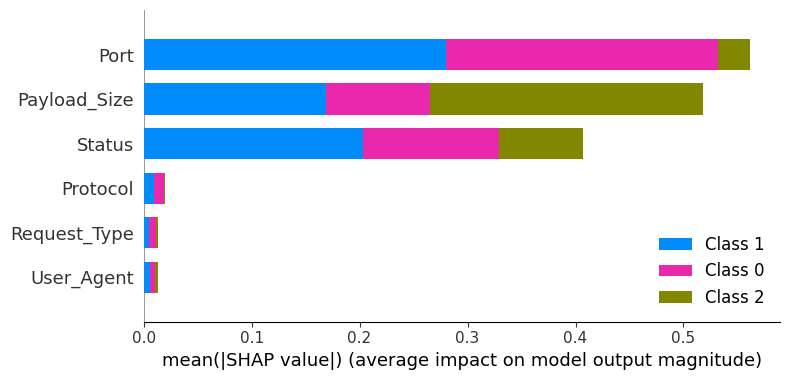

In [10]:
feature_names = list(X.columns)
class_names = list(target_encoder.classes_)

np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

In [11]:
shap_global = {}
for cls_idx, cls_name in enumerate(class_names):
    mean_abs = np.abs(shap_values[:, :, cls_idx]).mean(axis=0)
    shap_global[cls_name] = {feat: round(float(val), 6) for feat, val in zip(feature_names, mean_abs)}

shap_global_json = json.dumps(shap_global, indent=2, ensure_ascii=False)
print("SHAP - Importancia Global por Classe:")
print(shap_global_json)

SHAP - Importancia Global por Classe:
{
  "BotAttack": {
    "Port": 0.251781,
    "Request_Type": 0.006247,
    "Protocol": 0.009621,
    "Payload_Size": 0.096316,
    "User_Agent": 0.004768,
    "Status": 0.126012
  },
  "Normal": {
    "Port": 0.280436,
    "Request_Type": 0.005337,
    "Protocol": 0.009205,
    "Payload_Size": 0.16932,
    "User_Agent": 0.006142,
    "Status": 0.20348
  },
  "PortScan": {
    "Port": 0.029101,
    "Request_Type": 0.001732,
    "Protocol": 0.000822,
    "Payload_Size": 0.252459,
    "User_Agent": 0.002064,
    "Status": 0.077468
  }
}


In [12]:
n_local = 5
shap_local = []
for idx in range(n_local):
    sample_row = X_sample.iloc[idx]
    real_idx = X_sample.index[idx]
    entry = {
        "instance_features": {feat: round(float(sample_row[feat]), 4) for feat in feature_names},
        "true_label": class_names[int(y_test.loc[real_idx])],
        "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
        "shap_values_per_class": {}
    }
    for cls_idx, cls_name in enumerate(class_names):
        entry["shap_values_per_class"][cls_name] = {
            feat: round(float(shap_values[idx, f_idx, cls_idx]), 6)
            for f_idx, feat in enumerate(feature_names)
        }
    shap_local.append(entry)

shap_local_json = json.dumps(shap_local, indent=2, ensure_ascii=False)
print("SHAP - Explicacoes Locais (5 instancias):")
print(shap_local_json[:1000], "...")

SHAP - Explicacoes Locais (5 instancias):
[
  {
    "instance_features": {
      "Port": 2.0,
      "Request_Type": 1.0,
      "Protocol": 1.0,
      "Payload_Size": 1.6484,
      "User_Agent": 4.0,
      "Status": 1.0
    },
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "shap_values_per_class": {
      "BotAttack": {
        "Port": 0.045529,
        "Request_Type": -0.013085,
        "Protocol": 0.024018,
        "Payload_Size": 0.554967,
        "User_Agent": -0.020236,
        "Status": -0.103984
      },
      "Normal": {
        "Port": -0.035227,
        "Request_Type": 0.013103,
        "Protocol": -0.024109,
        "Payload_Size": -0.316372,
        "User_Agent": 0.019067,
        "Status": 0.189778
      },
      "PortScan": {
        "Port": -0.010302,
        "Request_Type": -1.9e-05,
        "Protocol": 9e-05,
        "Payload_Size": -0.238594,
        "User_Agent": 0.001169,
        "Status": -0.085794
      }
    }
  },
  {
    "instance_feature

In [13]:
import warnings

explainer_l = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

lime_explanations = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="X does not have valid feature names")
    for idx in range(n_local):
        sample_row = X_sample.iloc[idx]
        real_idx = X_sample.index[idx]

        exp = explainer_l.explain_instance(
            sample_row.values,
            model.predict_proba,
            num_features=6
        )

        lime_explanations.append({
            "instance_index": int(real_idx),
            "true_label": class_names[int(y_test.loc[real_idx])],
            "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
            "local_prediction_proba": {
                cls: round(float(p), 4)
                for cls, p in zip(class_names, model.predict_proba(sample_row.to_frame().T)[0])
            },
            "feature_contributions": [
                {"rule": rule, "weight": round(float(w), 6)} for rule, w in exp.as_list()
            ]
        })

lime_explanations_json = json.dumps(lime_explanations, indent=2, ensure_ascii=False)
print("LIME - Explicacoes Locais (5 instancias):")
print(lime_explanations_json[:1000], "...")

LIME - Explicacoes Locais (5 instancias):
[
  {
    "instance_index": 6094,
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "local_prediction_proba": {
      "BotAttack": 0.82,
      "Normal": 0.18,
      "PortScan": 0.0
    },
    "feature_contributions": [
      {
        "rule": "Port <= 3.00",
        "weight": 0.329508
      },
      {
        "rule": "Payload_Size > 0.91",
        "weight": -0.139365
      },
      {
        "rule": "0.00 < Status <= 1.00",
        "weight": 0.111214
      },
      {
        "rule": "Request_Type <= 1.00",
        "weight": 0.007599
      },
      {
        "rule": "2.00 < User_Agent <= 4.00",
        "weight": 0.007341
      },
      {
        "rule": "0.00 < Protocol <= 1.00",
        "weight": 0.006275
      }
    ]
  },
  {
    "instance_index": 8649,
    "true_label": "Normal",
    "predicted_label": "Normal",
    "local_prediction_proba": {
      "BotAttack": 0.0,
      "Normal": 1.0,
      "PortScan": 0.0
    },
    

# Construção dos Dados e Prompts (Two-Phase)

In [14]:
# ==========================
# METADADOS DO MODELO E DATASET
# ==========================
column_description = {
    "Port": "Communication port (encoded: 21=0, 22=1, 23=2, 25=3, 53=4, 80=5, 135=6, 443=7, 4444=8, 6667=9, 8080=10, 31337=11)",
    "Request_Type": "Request type (DNS=0, FTP=1, HTTP=2, HTTPS=3, SMTP=4, SSH=5, Telnet=6)",
    "Protocol": "Transport protocol (ICMP=0, TCP=1, UDP=2)",
    "Payload_Size": "Packet payload size (StandardScaler normalized)",
    "User_Agent": "Client agent (Mozilla/5.0=0, Nikto/2.1.6=1, Wget/1.20.3=2, curl/7.68.0=3, nmap/7.80=4, python-requests/2.25.1=5)",
    "Status": "Request status (Failure=0, Success=1)",
    "Scan_Type_Label": "Target variable: BotAttack=0, Normal=1, PortScan=2"
}

model_info = {
    "type": "Random Forest",
    "task": "Network intrusion detection from log entries",
    "target": "Scan_Type_Label",
    "classes": {"BotAttack": 0, "Normal": 1, "PortScan": 2},
    "features": list(X.columns),
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4)
}

# Samples (20 records)
train_sample = X_train.sample(20, random_state=42)
train_sample["Scan_Type_Label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

pred_sample = pd.DataFrame({"real": y_test, "predicted": y_pred})
pred_sample_json = pred_sample.sample(20, random_state=42).to_json(orient="records")

In [15]:
# ==========================
# SYSTEM MESSAGE
# ==========================
system_msg = (
    "You are an expert in Machine Learning, Explainable AI, and Cybersecurity. "
    "You will receive data about an intrusion detection model in multiple messages. "
    "After each message, briefly summarize the key data you received (do NOT analyze yet). "
    "When you receive 'OK, start your analysis.', produce your full structured analysis "
    "using ALL data from ALL previous messages."
)

# ==========================
# PHASE 1: Raw data only (no XAI)
# ==========================
phase1_msg1 = f"""I will send you data about a network intrusion detection model in parts.
After each part, briefly summarize what you received. Do NOT analyze yet.

# Part 1: Model Info & Column Descriptions

## Model
{json.dumps(model_info, indent=2, ensure_ascii=False)}

## Column Descriptions (all features are numerically encoded)
{json.dumps(column_description, indent=2, ensure_ascii=False)}"""

phase1_msg2 = f"""# Part 2: Training Data Sample (20 records)
{train_sample_json}"""

phase1_msg3 = f"""# Part 3: Real vs Predicted Labels (20 records)
{pred_sample_json}"""

phase1_task = f"""# OK, start your analysis.

You have received:
- Part 1: Model info (Random Forest, 3-class intrusion detection) + column descriptions
- Part 2: 20 training records
- Part 3: 20 real vs predicted labels

You do NOT have SHAP or LIME data yet. Based ONLY on the model info, training data patterns,
and prediction results, provide a structured analysis:

1. **Model Performance:** Analyze the real vs predicted labels. Identify misclassifications and patterns.

2. **Feature Analysis:** Based on the training data, which features seem most important for distinguishing
   BotAttack vs Normal vs PortScan? Explain from a cybersecurity perspective.

3. **Misclassification Hypotheses:** For each misclassification, hypothesize why the model got it wrong
   based on the feature values.

4. **Cybersecurity Insights:** What patterns in the data are most useful for a SOC analyst?

5. **Model Reliability:** Based on what you can see, how reliable is this model? What are its weaknesses?

6. **Improvement Suggestions:** Concrete improvements you would recommend.

Use numbered sections and subsections."""

# ==========================
# PHASE 2: Add XAI data to the SAME chat, ask again
# ==========================
phase2_msg_shap_global = f"""# NEW DATA: SHAP Global Feature Importance

I now have SHAP (SHapley Additive exPlanations) results for the model.
Mean |SHAP| per feature per class, computed over {len(X_sample)} test samples:
{shap_global_json}"""

phase2_msg_shap_local = f"""# NEW DATA: SHAP Local Explanations (5 instances)
{shap_local_json}"""

phase2_msg_lime = f"""# NEW DATA: LIME Local Explanations (same 5 instances as SHAP)
{lime_explanations_json}"""

phase2_task = f"""# OK, now revise your analysis with the XAI evidence.

You previously analyzed the model based only on raw data and predictions.
Now you have received SHAP and LIME explanations.

Key SHAP global values (for reference):
{shap_global_json}

Provide a REVISED and UPDATED analysis:

1. **Global Feature Importance (SHAP):** Interpret the importance ranking for each class.
   How does this compare to your earlier feature analysis (without XAI)?
   What did you get right? What did you get wrong?

2. **Local Explanations (SHAP + LIME):** For each of the 5 instances, explain the prediction
   using both SHAP values AND LIME rules. Where do they agree? Where do they disagree?

3. **Revised Misclassification Analysis:** Do the SHAP/LIME data confirm or contradict your
   earlier hypotheses about misclassifications?

4. **Updated Cybersecurity Insights:** With XAI evidence, what are the strongest indicators
   of BotAttack vs PortScan? How should a SOC analyst use these?

5. **Model Reliability (Revised):** Assess coherence between SHAP, LIME, and data patterns.
   Has your confidence in the model changed?

6. **Updated Improvement Suggestions:** Concrete improvements based on XAI evidence.

Be explicit about what changed in your understanding after seeing the XAI data.
Use numbered sections and subsections."""

# ==========================
# BUILD CONVERSATION STRUCTURE
# ==========================
# Phase 1 chunks (raw data -> first analysis)
phase1_chunks = [
    {"user": phase1_msg1},
    {"user": phase1_msg2},
    {"user": phase1_msg3},
    {"user": phase1_task, "is_analysis": True},
]

# Phase 2 chunks (XAI data -> revised analysis, continues same chat)
phase2_chunks = [
    {"user": phase2_msg_shap_global},
    {"user": phase2_msg_shap_local},
    {"user": phase2_msg_lime},
    {"user": phase2_task, "is_analysis": True},
]

print("Phase 1 (raw data):")
for i, chunk in enumerate(phase1_chunks, 1):
    print(f"  Msg {i}: {len(chunk['user'])} chars {'[ANALYSIS REQUEST]' if chunk.get('is_analysis') else ''}")

print("\nPhase 2 (+ XAI data):")
for i, chunk in enumerate(phase2_chunks, 1):
    print(f"  Msg {i}: {len(chunk['user'])} chars {'[ANALYSIS REQUEST]' if chunk.get('is_analysis') else ''}")

total = sum(len(c["user"]) for c in phase1_chunks + phase2_chunks)
print(f"\nTotal across all messages: {total} chars")

Phase 1 (raw data):
  Msg 1: 1207 chars 
  Msg 2: 2349 chars 
  Msg 3: 549 chars 
  Msg 4: 1097 chars [ANALYSIS REQUEST]

Phase 2 (+ XAI data):
  Msg 1: 721 chars 
  Msg 2: 4687 chars 
  Msg 3: 3822 chars 
  Msg 4: 1839 chars [ANALYSIS REQUEST]

Total across all messages: 16271 chars


# Execução: Two-Phase per Model

In [16]:
# ==========================
# TWO-PHASE LOOP: SAME CHAT, RAW DATA FIRST, THEN XAI
# ==========================
client = OpenAI(
    base_url=OLLAMA_BASE_URL,
    api_key="ollama",
    timeout=httpx.Timeout(REQUEST_TIMEOUT, connect=30.0),
)

results = {}
timings = {}
previous_model = None

for model_cfg in models:
    model_name = model_cfg["name"]
    model_size = model_cfg["size"]

    if previous_model:
        !ollama stop $previous_model
        time.sleep(2)

    print(f"\n{'='*60}")
    print(f"Modelo: {model_name} (tier: {model_size})")
    print(f"{'='*60}")

    messages = [{"role": "system", "content": system_msg}]
    max_tokens_analysis = 16384 if model_size == "large" else 8192
    model_results = {}

    t_start = time.time()
    try:
        # ---- PHASE 1: Raw data ----
        print(f"\n  --- PHASE 1: Raw data only ---")
        n_p1 = len(phase1_chunks)
        for i, chunk in enumerate(phase1_chunks):
            is_analysis = chunk.get("is_analysis", False)
            messages.append({"role": "user", "content": chunk["user"]})

            if not is_analysis:
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=256
                )
                summary = response.choices[0].message.content.strip()
                messages.append({"role": "assistant", "content": summary})
                print(f"  P1 Msg {i+1}/{n_p1} sent -> {summary[:80]}")
            else:
                print(f"  P1 Msg {i+1}/{n_p1} sent -> requesting Phase 1 analysis...")
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=max_tokens_analysis
                )
                phase1_result = response.choices[0].message.content
                messages.append({"role": "assistant", "content": phase1_result})
                model_results["phase1_without_xai"] = phase1_result
                print(f"  Phase 1 done: {len(phase1_result)} chars")

        # ---- PHASE 2: Add XAI data (same chat) ----
        print(f"\n  --- PHASE 2: Adding SHAP + LIME ---")
        n_p2 = len(phase2_chunks)
        for i, chunk in enumerate(phase2_chunks):
            is_analysis = chunk.get("is_analysis", False)
            messages.append({"role": "user", "content": chunk["user"]})

            if not is_analysis:
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=256
                )
                summary = response.choices[0].message.content.strip()
                messages.append({"role": "assistant", "content": summary})
                print(f"  P2 Msg {i+1}/{n_p2} sent -> {summary[:80]}")
            else:
                print(f"  P2 Msg {i+1}/{n_p2} sent -> requesting Phase 2 analysis...")
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=max_tokens_analysis
                )
                phase2_result = response.choices[0].message.content
                messages.append({"role": "assistant", "content": phase2_result})
                model_results["phase2_with_xai"] = phase2_result
                print(f"  Phase 2 done: {len(phase2_result)} chars")

        elapsed = time.time() - t_start
        timings[model_name] = elapsed
        results[model_name] = model_results
        print(f"\n  Total: {elapsed:.1f}s")

    except Exception as e:
        elapsed = time.time() - t_start
        timings[model_name] = elapsed
        model_results["error"] = str(e)
        results[model_name] = model_results
        print(f"  Error: {e} ({elapsed:.1f}s)")

    previous_model = model_name

if previous_model:
    !ollama stop $previous_model

print("\nAll models completed.\n")
print("Time per model:")
for name, t in timings.items():
    print(f"  {name}: {t:.1f}s")


Modelo: glm-4.7-flash:latest (tier: medium)

  --- PHASE 1: Raw data only ---
  P1 Msg 1/4 sent -> 
  P1 Msg 2/4 sent -> 
  P1 Msg 3/4 sent -> 
  P1 Msg 4/4 sent -> requesting Phase 1 analysis...
  Phase 1 done: 5789 chars

  --- PHASE 2: Adding SHAP + LIME ---
  P2 Msg 1/4 sent -> 
  P2 Msg 2/4 sent -> 
  P2 Msg 3/4 sent -> 
  P2 Msg 4/4 sent -> requesting Phase 2 analysis...
  Phase 2 done: 5015 chars

  Total: 970.8s
]11;?\⠙ ⠙ ⠸ 
Modelo: qwen3:14b (tier: medium)

  --- PHASE 1: Raw data only ---
  P1 Msg 1/4 sent -> 
  P1 Msg 2/4 sent -> 
  P1 Msg 3/4 sent -> 
  P1 Msg 4/4 sent -> requesting Phase 1 analysis...
  Phase 1 done: 4404 chars

  --- PHASE 2: Adding SHAP + LIME ---
  P2 Msg 1/4 sent -> 
  P2 Msg 2/4 sent -> 
  P2 Msg 3/4 sent -> 
  P2 Msg 4/4 sent -> requesting Phase 2 analysis...
  Phase 2 done: 5523 chars

  Total: 373.2s
]11;?\⠋ ⠙ 
Modelo: gpt-oss:20b (tier: medium)

  --- PHASE 1: Raw data only ---
  P1 Msg 1/4 sent -> **Summary – Part 1**

- Model: Random Forest

# Resultados

In [17]:
for model_name, model_results in results.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {model_name}")
    print(f"{'='*60}")

    if "phase1_without_xai" in model_results:
        print(f"\n--- PHASE 1: Without XAI ({len(model_results['phase1_without_xai'])} chars) ---\n")
        print(model_results["phase1_without_xai"])

    if "phase2_with_xai" in model_results:
        print(f"\n--- PHASE 2: With XAI ({len(model_results['phase2_with_xai'])} chars) ---\n")
        print(model_results["phase2_with_xai"])

    if "error" in model_results:
        print(f"\nERROR: {model_results['error']}")

    print()


MODELO: glm-4.7-flash:latest

--- PHASE 1: Without XAI (5789 chars) ---

### 1. Model Performance

**Evaluation based on provided sample:**
The evaluation of the provided Real vs. Predicted data (Part 3) reveals a **perfect match rate of 100%** across the 20 samples. All records predicted by the model correspond exactly to their ground truth labels.

*   **Accuracy:** 20/20 matches.
*   **Class Specifics:**
    *   **Normal Traffic (Class 1):** Successfully predicted 15 times.
    *   **PortScan (Class 2):** Successfully predicted 1 time.
    *   **BotAttack (Class 0):** Successfully predicted 2 times.

**Context from Part 1:**
The model specification lists a training set `accuracy` of **0.997**, which indicates high generalization capability. The perfect performance on this specific sample suggests the model has successfully learned the primary discriminators between benign traffic and scan/attack patterns within the encoded feature space.

### 2. Feature Analysis

By analyzing the f

In [18]:
with open("resultados_enforce_knowledge.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print("Resultados salvos em resultados_enforce_knowledge.json")

Resultados salvos em resultados_enforce_knowledge.json
